In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import tqdm
import copy
import numpy as np

In [2]:
from src.utils.normalizer import Normalizer
from typing import Optional, Tuple  

In [3]:
class Sparse(nn.Module):
    
    def __init__(self, original_weight: torch.Tensor, 
                 N:int = 2, 
                 M:int = 4,
                 n_permutations:int = 10,
                 gamma: float = -0.1,
                 xi:float = 1.1) -> None:
        
        super(Sparse, self).__init__()
        
        self.weight = nn.Parameter(torch.randn_like(original_weight) * torch.std(original_weight), requires_grad=True)
        self.sparse_mask = nn.Parameter(torch.zeros_like(original_weight), requires_grad=True)
        self.sparse_mask.data.uniform_(-1, 1)
        
        self.permutation_matricies = nn.Parameter(torch.zeros((n_permutations, original_weight.shape[1], original_weight.shape[1])), requires_grad=True)
        
        self.permutation_matricies.data.uniform_(-1, 1)
        
        self.permutation_scales = nn.Parameter(torch.randn(n_permutations, original_weight.shape[1])/n_permutations, requires_grad=True)
        
        self.N = N
        self.M = M
        self.gamma = gamma
        self.xi = xi
        self.n_permutations = n_permutations
        
    def sigmoid(self, x: torch.Tensor) -> torch.Tensor:
        #scaled and clipped sigmoid function
        return torch.clip((self.xi-self.gamma) * torch.sigmoid(x) + self.gamma, 0, 1)
    
    def softmax(self, x: torch.Tensor) -> torch.Tensor:
        return F.softmax(x, dim=-1)
    
    def calculate_permutation_matrices(self) -> torch.Tensor:
        return self.softmax(self.permutation_matricies)
        
        
    def forward(self) -> torch.Tensor:
        # Apply the sparse mask to the weight
        sparse_weight = self.weight * self.sigmoid(self.sparse_mask)
        # print("Sparse weight shape:", sparse_weight)
        # Apply the permutation matrices and scales
        # print(self.softmax(self.permutation_matricies),self.permutation_scales)
        weight = torch.einsum("ij,kjl,kl->il",
                              sparse_weight,
                              self.calculate_permutation_matrices(),    
                              self.permutation_scales)
        
        return weight
    
    def binary_penalty_sparse(self, beta: float = 1.0) -> torch.Tensor:
        # Binary penalty for the sparse mask
        # print(torch.abs(2*self.sigmoid(self.permutation_matricies)-1))
        # print(torch.abs(2*self.sigmoid(self.sparse_mask)-1))
        # raise ValueError("Binary penalty is not implemented yet.")
        return torch.mean(1-torch.abs(2*self.sigmoid(self.sparse_mask)-1)**beta)
    
    def binary_penalty_permutation(self, beta: float = 1.0) -> torch.Tensor:
        
        #slightly more complex binary penalty for the permutation matricies
        bias_point = 1/self.weight.shape[1]
        
        permutation_matricies = self.calculate_permutation_matrices()
        
        binary_loss_smaller = (1-torch.abs(permutation_matricies/bias_point - 1)**beta)
        binary_loss_larger = (1-torch.abs((permutation_matricies - bias_point)/(1-bias_point))**beta)
        
        binary_loss = torch.where(permutation_matricies < bias_point,
                    binary_loss_smaller, binary_loss_larger)
        return torch.mean(binary_loss)
        
    
    def sparsity_penalty(self, l2: bool = True
                         ) -> torch.Tensor:
        # Sparsity penalty for the sparse mask
        if l2:
            return torch.sqrt(torch.mean(torch.square(torch.sum(self.sigmoid(self.sparse_mask).view(-1, self.M), dim=1) - self.N)))
        else:
            return torch.mean(torch.abs(torch.sum(self.sigmoid(self.sparse_mask).view(-1, self.M), dim=1) - self.N))
        
    def permutation_penalty(self,l2: bool = True):
        permutation_matricies = self.calculate_permutation_matrices()
        
        mul1 = torch.sum(permutation_matricies, dim=1) - 1
        mul2 = torch.sum(permutation_matricies, dim=2) - 1
        
        if l2:
            return torch.sqrt(torch.mean(torch.square(mul1))) #+ torch.mean(torch.square(mul2)))
        else:
            return torch.mean(torch.abs(mul1))# + torch.mean(torch.abs(mul2))
        
    def get_sparse_mask(self) -> torch.Tensor:
        sparse_mask_soft = self.sigmoid(self.sparse_mask)
        
        sparse_mask_hard = torch.zeros_like(sparse_mask_soft)
        
        #for each M elements in the sparse mask, set the top N elements to 1 and the rest to 0
        idxs = torch.argsort(sparse_mask_soft.view(-1, self.M), dim=1, descending=True)[:, :self.N]
        sparse_mask_hard = sparse_mask_hard.view(-1, self.M).scatter_(1, idxs, 1)
        return sparse_mask_hard.view_as(sparse_mask_soft)
    
    # def get_sparse_
    def get_permutation_matrices(self) -> torch.Tensor:
        
        permutation_matricies_soft = self.calculate_permutation_matrices()
        
        soft_indicies_sorted = torch.argsort(permutation_matricies_soft.view(permutation_matricies_soft.shape[0], -1), dim=1, descending=True)
        
        
        permutation_input_sorted = soft_indicies_sorted%self.weight.shape[1]
        permutation_output_sorted = soft_indicies_sorted//self.weight.shape[1] #both are of shape (n_permutations, weight.shape[1] * weight.shape[1])
        
        hard_permutation_idxs = -torch.ones((self.n_permutations, self.weight.shape[1]), dtype=torch.long)
        used_input_idxs = [set() for _ in range(self.n_permutations)]   
        
        for i in range(permutation_output_sorted.shape[1]):
            for j in range(self.n_permutations):
                input_idx = permutation_input_sorted[j, i].item()
                output_idx = permutation_output_sorted[j, i].item()
                
                if input_idx not in used_input_idxs[j] and hard_permutation_idxs[j, output_idx] == -1:
                    hard_permutation_idxs[j, output_idx] = input_idx
                    used_input_idxs[j].add(input_idx)
            
            if torch.all(hard_permutation_idxs != -1):
                break
        
        #create the hard permutation matrices
        hard_permutation_matrices = torch.zeros((self.n_permutations, self.weight.shape[1], self.weight.shape[1]), dtype=torch.float32)
        for j in range(self.n_permutations):
            for i in range(self.weight.shape[1]):
                if hard_permutation_idxs[j, i] != -1:
                    hard_permutation_matrices[j, hard_permutation_idxs[j, i], i] = 1.0
                else:
                    raise ValueError("Not all input indices were used in the permutation matrix.")
        
        return hard_permutation_matrices
    
    def real_weight(self)->torch.Tensor:
        #get the real weight matrix after applying the sparse mask and permutation matrices
        sparse_weight = self.get_sparse_mask()
        permutation_matrices = self.get_permutation_matrices()
        
        weight = torch.einsum("ij,kjl,kl->il",
                              self.weight * sparse_weight,
                              permutation_matrices,    
                              self.permutation_scales)
        return weight
    
        
        
        
        
    
    
        
        

In [4]:
device = "cuda:7"

weight_path = "./models/meta-llama/Llama-2-7b-hf/original_weights/layer_0/self_attn.q_proj.pt"
hessian_diag = weight_path.replace("original_weights", "hessianDiags/seed_0/pajama/128")


weight = torch.load(weight_path, map_location=device)["weight"].to(torch.float32).detach()
hessian_diag = torch.load(hessian_diag, map_location=device)["hessianDiag"].to(torch.float32    )

In [5]:
S = Sparse(original_weight=weight,
                    N=2, 
                    M=4,
                    n_permutations=10,
                    gamma=-0.1,
                    xi=1.1).to(device)

print(S())
# print(S.real_weight())

tensor([[-1.2812e-05, -3.2306e-05, -1.2992e-05,  ..., -1.2723e-06,
         -4.4557e-05, -5.6481e-05],
        [ 7.1925e-06,  6.1272e-06,  7.8499e-06,  ..., -2.8595e-07,
         -7.4488e-05, -6.2543e-05],
        [-1.8067e-05, -1.8375e-05,  1.8078e-05,  ...,  1.7661e-05,
          3.3022e-05,  7.2835e-05],
        ...,
        [-2.8925e-05,  1.0922e-05, -8.2394e-06,  ..., -8.7915e-06,
          4.9605e-05,  2.7657e-05],
        [-5.3474e-05, -9.1646e-06, -1.2032e-05,  ..., -4.2080e-06,
          1.0584e-04,  1.0293e-04],
        [ 3.4090e-05,  3.1147e-05,  1.2594e-05,  ..., -1.8671e-05,
         -1.9116e-04, -1.6722e-04]], device='cuda:7', grad_fn=<ViewBackward0>)


In [10]:
S = Sparse(original_weight=weight,
                    N=2, 
                    M=4,
                    n_permutations=10,
                    gamma=-0.1,
                    xi=1.1).to(device)

optim = torch.optim.Adam(S.parameters(), lr=1e-1)   

n_iters = 1000

betas_sparse = np.linspace(2,1.1, n_iters)
betas_permutation = np.linspace(1.5,1, n_iters)
print(np.linspace(2,1,1, n_iters//2).shape)
print(np.linspace(1.1, 1.5, n_iters//2).shape)
print(betas_permutation.shape)
print("len betas_permutation:", len(betas_permutation))
assert len(betas_sparse) == len(betas_permutation), "betas_sparse and betas_permutation must have the same length"
# print("betas_permutation:", betas_permutation)
# raise ValueError("betas_sparse:", betas_sparse)
lambda_binary_sparse, lambda_binary_permutation, lambda_sparsity, lambda_permutation = 0.1, 0.1, 0.1, 0.1
recon_loss_scaling = 1e+1

for i in tqdm.tqdm(range(n_iters)):
    
    optim.zero_grad()
    
    # Forward pass
    sparse_weight = S()
    # print("beta:", betas[i])
    sparse_binary = S.binary_penalty_sparse(beta=betas_sparse[i])
    permutation_binary = S.binary_penalty_permutation(beta=1)
    
    sparsity_penalty = S.sparsity_penalty(l2=False)
    permutation_penalty = S.permutation_penalty(l2=False)
    
    # Compute the loss
    # recon_loss = F.mse_loss(sparse_weight, weight)
    # loss = binary_penalty * lambda_binary 
    loss = (sparse_binary * lambda_binary_sparse +
            permutation_binary * lambda_binary_permutation +
            sparsity_penalty * lambda_sparsity + 
            permutation_penalty * lambda_permutation) #+ recon_loss*recon_loss_scaling
    
    # Backward pass
    loss.backward()
    optim.step()
    if i % 10 == 0:
        print(f"Iteration {i}, Loss: {loss.item()}, "
              f"Sparse Binary Penalty: {sparse_binary.item()}, "
              f"Permutation Binary Penalty: {permutation_binary.item()}, "
              f"Sparsity Penalty: {sparsity_penalty.item()}, "
              f"Permutation Penalty: {permutation_penalty.item()}, "
                # f"Reconstruction Loss: {recon_loss.item()}"
                  )
    
    

(1,)
(500,)
(1000,)
len betas_permutation: 1000


  0%|          | 1/1000 [00:00<02:51,  5.84it/s]

Iteration 0, Loss: 0.19275681674480438, Sparse Binary Penalty: 0.8908721208572388, Permutation Binary Penalty: 0.7627535462379456, Sparsity Penalty: 0.26697826385498047, Permutation Penalty: 0.006964182946830988, 


  1%|          | 12/1000 [00:01<03:28,  4.74it/s]

Iteration 10, Loss: 0.17031808197498322, Sparse Binary Penalty: 0.8834409713745117, Permutation Binary Penalty: 0.7506763339042664, Sparsity Penalty: 0.06679818034172058, Permutation Penalty: 0.0022652912884950638, 


...

 98%|█████████▊| 982/1000 [02:46<00:04,  4.32it/s]

Iteration 980, Loss: 0.032179635018110275, Sparse Binary Penalty: 0.0, Permutation Binary Penalty: 0.31818103790283203, Sparsity Penalty: 0.0, Permutation Penalty: 0.0036153115797787905, 


 99%|█████████▉| 992/1000 [02:48<00:01,  4.32it/s]

Iteration 990, Loss: 0.031837791204452515, Sparse Binary Penalty: 0.0, Permutation Binary Penalty: 0.3146289885044098, Sparsity Penalty: 0.0, Permutation Penalty: 0.0037488953676074743, 


100%|██████████| 1000/1000 [02:49<00:00,  5.91it/s]


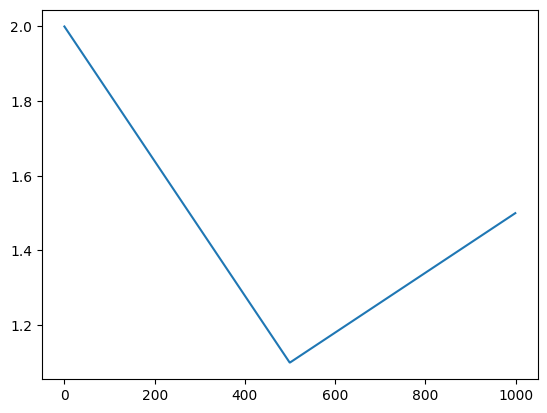

In [11]:
import matplotlib.pyplot as plt
plt.plot(np.concat([np.linspace(2,1.1, n_iters//2), np.linspace(1.1, 1.5, n_iters//2)]))

In [12]:
S.sigmoid(S.sparse_mask).view(-1, S.M)

tensor([[1., 0., 0., 1.],
        [1., 1., 0., 0.],
        [0., 1., 0., 1.],
        ...,
        [0., 1., 1., 0.],
        [1., 1., 0., 0.],
        [1., 0., 0., 1.]], device='cuda:7', grad_fn=<ViewBackward0>)

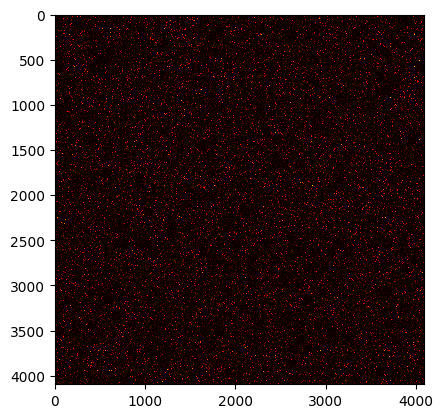

In [13]:
import matplotlib.pyplot as plt
plt.imshow(S.calculate_permutation_matrices()[1].detach().cpu().numpy(), cmap='hot', interpolation='nearest')

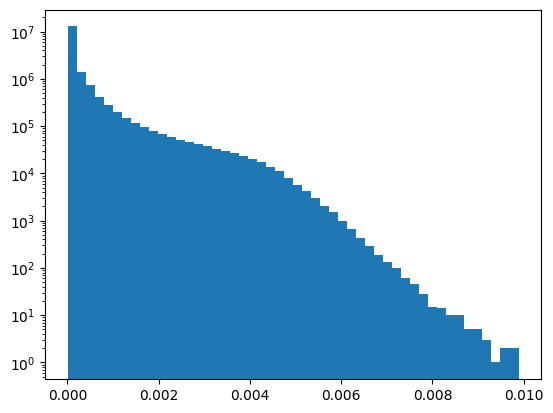

In [14]:
plt.hist(S.calculate_permutation_matrices()[0].detach().cpu().numpy().flatten(), bins=50)
plt.yscale('log')

In [15]:
torch.max(S.calculate_permutation_matrices()[0])

tensor(0.0099, device='cuda:7', grad_fn=<MaxBackward1>)

In [ ]:
S()

In [ ]:
weight

In [ ]:
#try just standard naive pruning
importances = torch.abs(weight)  # Example importance scores based on absolute values of weights

idxs = torch.argsort(importances.view(-1, S.M), dim=1, descending=True)[:, :S.N]
sparse_mask_hard = torch.zeros_like(importances)
sparse_mask_hard = sparse_mask_hard.view(-1, S.M).scatter_(1, idxs, 1)
sparse_mask_hard = sparse_mask_hard.view_as(importances)
# Apply the sparse mask to the weight
sparse_weight = weight * sparse_mask_hard

#get the mse
recon_loss_naive = F.mse_loss(sparse_weight, weight)
print(f"Naive Reconstruction Loss: {recon_loss_naive.item()}")

In [ ]:
print("our method reconstruction loss:", recon_loss.item())